In [1]:
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd
import scipy.stats as stats

In [4]:
# Target variable
df = pd.read_csv("../Code/159_planets_all_columns_with_final_co2_A_H.csv")
AH = df['A_H']

# Parameters to test
params = {
    "Temperature": df['pl_Teq'],
    "g": df['g_planet_cgs'],
    "1/g": 1/df['g_planet_cgs'],
    "Planet Radius": df['pl_rade'],
    "Star Radius": df['st_rad'],
    "Semi-Major Axis": df['pl_orbsmax'],
    "J-Magnitude": df['sy_jmag'],
    "Transit Duration": df['pl_trandur']
}

results = []

for name, values in params.items():
    mask = np.isfinite(values) & np.isfinite(AH)
    r, p = stats.pearsonr(values[mask], AH[mask])
    results.append([name, r, p])

# Create results table
corr_df = pd.DataFrame(results, columns=["parameter", "pearson_r", "p_value"])

# Save CSV
#corr_df.to_csv("AH_correlations.csv", index=False)

print(corr_df)

          parameter  pearson_r       p_value
0       Temperature  -0.252779  1.306041e-03
1                 g  -0.575161  2.206943e-15
2               1/g   0.832095  4.907325e-42
3     Planet Radius   0.034630  6.647629e-01
4       Star Radius  -0.032093  6.879916e-01
5   Semi-Major Axis   0.199841  1.155208e-02
6       J-Magnitude   0.244832  1.868761e-03
7  Transit Duration   0.112560  1.577675e-01


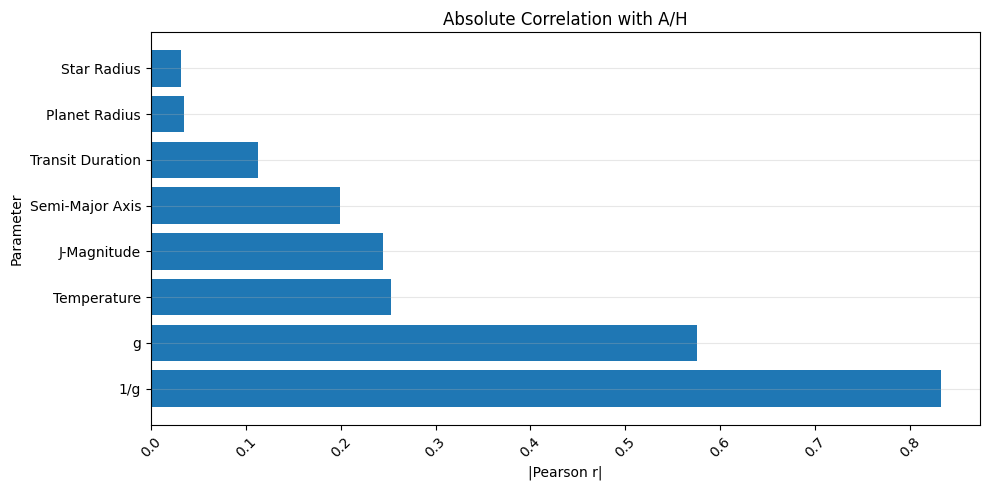

In [5]:
# feel free to mess with the plotting code 

# Add absolute correlation column
corr_df["abs_r"] = corr_df["pearson_r"].abs()

# Sort by absolute correlation
corr_df_sorted = corr_df.sort_values("abs_r", ascending=False)

plt.figure(figsize=(10,5))

plt.barh(corr_df_sorted["parameter"], corr_df_sorted["abs_r"])

plt.xlabel("|Pearson r|")
plt.ylabel("Parameter")
plt.title("Absolute Correlation with A/H")

plt.xticks(rotation=45)
plt.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()